# Voluntary Post-Epigame Feedback

This notebook cleans, summarizes, visualizes, and exports nine submissions from the voluntary post-Epigame feedback survey at the American University of Iraq, Baghdad (AUIB).

The analysis is descriptive. Submitted forms may differ from feedback that was not submitted, so results characterize these nine submissions only, not all randomized or behaviorally active participants. No causal, randomized-arm, prevalence, or population-representative comparisons are attempted. Timestamps and response-level text are excluded from displays and analytic exports. Free-text summaries use documented keyword rules, permit overlapping themes, and are reported only when at least three respondents mention a theme; they are not a substitute for validated qualitative analysis.

## 1. Configure Paths and Import Libraries

In [1]:
from pathlib import Path
import re
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

DATA_PATH = Path('data/202/Post-Epigame-Feedback-Responses.xlsx')
OUTPUT_DIR = Path('output/202/post-epigame-feedback')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
})
sns.set_theme(style='whitegrid', context='notebook')

assert DATA_PATH.exists(), f'Workbook not found: {DATA_PATH}'
print(f'Input: {DATA_PATH}')
print(f'Outputs: {OUTPUT_DIR}')

Input: data/202/Post-Epigame-Feedback-Responses.xlsx
Outputs: output/202/post-epigame-feedback


## 2. Inspect Workbook Structure

The workbook is inspected without displaying response values. This identifies worksheets, dimensions, column types, and fields that may contain direct identifiers. The source workbook is never modified.

In [3]:
workbook = pd.ExcelFile(DATA_PATH, engine='openpyxl')
workbook_structure = []
for sheet_name in workbook.sheet_names:
    sheet = pd.read_excel(DATA_PATH, sheet_name=sheet_name, engine='openpyxl')
    workbook_structure.append({
        'sheet': sheet_name,
        'rows': len(sheet),
        'columns': len(sheet.columns),
        'completely_empty_rows': int(sheet.isna().all(axis=1).sum()),
    })

structure_table = pd.DataFrame(workbook_structure)
display(structure_table)

raw_preview = pd.read_excel(DATA_PATH, sheet_name=workbook.sheet_names[0], engine='openpyxl')
column_audit = pd.DataFrame({
    'column_number': np.arange(1, len(raw_preview.columns) + 1),
    'dtype': raw_preview.dtypes.astype(str).to_numpy(),
    'nonmissing': raw_preview.notna().sum().to_numpy(),
    'unique_nonmissing': raw_preview.nunique(dropna=True).to_numpy(),
})
display(column_audit)
print('Response values and column labels are intentionally not previewed.')
assert workbook.sheet_names == ['Form Responses 1']
assert raw_preview.shape == (9, 9)

,sheet,rows,columns,completely_empty_rows
0,Form Responses 1,9,9,0


,column_number,dtype,nonmissing,unique_nonmissing
0,1,datetime64[ns],9,9
1,2,int64,9,4
2,3,int64,9,5
3,4,object,7,7
4,5,object,8,8
5,6,object,7,7
6,7,object,8,8
7,8,object,7,7
8,9,object,6,5


Response values and column labels are intentionally not previewed.


## 3. Load and Standardize Survey Submissions

The AUIB form is validated against its expected nine-column schema. Whitespace-only and common missing-value strings are standardized to missing. The timestamp is excluded from the analytic table, and the source frame is discarded after cleaning.

## 4. Audit Completeness and Voluntary-Submission Coverage

Completion is reported relative to the nine submitted forms. A survey submission rate among all eligible participants is not calculated because the workbook does not establish the invitation denominator.

## 5. Classify Survey Question Types

The map below classifies source fields before exclusions. This workbook contains one timestamp, two numeric ratings, and six free-text fields; it contains no binary or multiple-selection item.

In [4]:
source_data = pd.read_excel(DATA_PATH, sheet_name='Form Responses 1', engine='openpyxl')

missing_tokens = {'', '-', '--', 'na', 'n/a', 'nan', 'null'}
def clean_cell(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, str):
        cleaned = re.sub(r'\s+', ' ', unicodedata.normalize('NFKC', value)).strip()
        return np.nan if cleaned.casefold() in missing_tokens else cleaned
    return value

clean_source = source_data.map(clean_cell).dropna(how='all').reset_index(drop=True)
del source_data
columns = list(clean_source.columns)
expected_prefixes = [
    'Timestamp',
    'How would you rate your overall experience',
    'On a scale of 1-10, how easy was it',
    'Which particular gamification elements did you enjoy',
    'Were there any parts of the epidemic game that you did not enjoy',
    'The Epigames app is a research prototype',
    'If you could change or add one thing to the app',
    "What changes or improvements would you suggest for the avatars' visual design",
    'Any other comments or ideas',
]
assert clean_source.shape == (9, 9)
assert all(str(column).startswith(prefix) for column, prefix in zip(columns, expected_prefixes))

question_map = pd.DataFrame([
    {'variable': 'timestamp', 'source_column': 1, 'type': 'metadata', 'reported': False},
    {'variable': 'overall_experience', 'source_column': 2, 'type': 'rating_1_to_5', 'reported': True},
    {'variable': 'ease_of_use', 'source_column': 3, 'type': 'rating_1_to_10', 'reported': True},
    {'variable': 'enjoyed', 'source_column': 4, 'type': 'free_text', 'reported': 'themes with count >=3 only'},
    {'variable': 'frustrations', 'source_column': 5, 'type': 'free_text', 'reported': 'themes with count >=3 only'},
    {'variable': 'technical_issues', 'source_column': 6, 'type': 'free_text', 'reported': 'themes with count >=3 only'},
    {'variable': 'improvements', 'source_column': 7, 'type': 'free_text', 'reported': 'themes with count >=3 only'},
    {'variable': 'avatar_improvements', 'source_column': 8, 'type': 'free_text', 'reported': 'themes with count >=3 only'},
    {'variable': 'other_comments', 'source_column': 9, 'type': 'free_text', 'reported': 'completion only'},
])
display(question_map)

analysis_data = pd.DataFrame({
    'overall_experience': pd.to_numeric(clean_source.iloc[:, 1], errors='coerce'),
    'ease_of_use': pd.to_numeric(clean_source.iloc[:, 2], errors='coerce'),
    'enjoyed': clean_source.iloc[:, 3],
    'frustrations': clean_source.iloc[:, 4],
    'technical_issues': clean_source.iloc[:, 5],
    'improvements': clean_source.iloc[:, 6],
    'avatar_improvements': clean_source.iloc[:, 7],
    'other_comments': clean_source.iloc[:, 8],
})

assert len(analysis_data) == 9
assert analysis_data['overall_experience'].between(1, 5).all()
assert analysis_data['ease_of_use'].between(1, 10).all()
assert not any('timestamp' in column.casefold() for column in analysis_data.columns)

print(f'Submitted forms: {len(analysis_data)}')
print('Response-level values are intentionally not displayed or exported.')

,variable,source_column,type,reported
0,timestamp,1,metadata,False
1,overall_experience,2,rating_1_to_5,True
2,ease_of_use,3,rating_1_to_10,True
3,enjoyed,4,free_text,themes with count >=3 only
4,frustrations,5,free_text,themes with count >=3 only
5,technical_issues,6,free_text,themes with count >=3 only
6,improvements,7,free_text,themes with count >=3 only
7,avatar_improvements,8,free_text,themes with count >=3 only
8,other_comments,9,free_text,completion only


Submitted forms: 9
Response-level values are intentionally not displayed or exported.


## 6. Summarize Closed-Ended Submissions

There are no language, binary, or multiple-selection questions in this workbook.

## 7. Analyze Rating Questions

Overall experience uses a 1--5 scale and ease of use uses a 1--10 scale. Favorable/top-box ratings are defined before analysis as 4--5 and 8--10, respectively. Each item uses its own nonmissing-submission denominator. Counts remain primary because only nine forms were submitted; percentages are included only to make denominators explicit.

## 8. Analyze Multiple-Selection Questions

No delimiter-separated multiple-selection question was observed, so no option-level analysis is performed.

In [5]:
THEME_REPORTING_THRESHOLD = 3

rating_specs = {
    'overall_experience': {'label': 'Overall experience (1-5)', 'minimum': 1, 'maximum': 5, 'favorable_minimum': 4},
    'ease_of_use': {'label': 'Ease of app use (1-10)', 'minimum': 1, 'maximum': 10, 'favorable_minimum': 8},
}

rating_rows = []
for variable, specification in rating_specs.items():
    values = analysis_data[variable].dropna()
    favorable_count = int((values >= specification['favorable_minimum']).sum())
    rating_rows.append({
        'variable': variable,
        'item': specification['label'],
        'n': len(values),
        'missing': int(analysis_data[variable].isna().sum()),
        'mean': values.mean(),
        'sd': values.std(ddof=1),
        'median': values.median(),
        'q1': values.quantile(0.25),
        'q3': values.quantile(0.75),
        'minimum': values.min(),
        'maximum': values.max(),
        'favorable_definition': f">={specification['favorable_minimum']}",
        'favorable_count': favorable_count,
        'favorable_percent': 100 * favorable_count / len(values),
    })
rating_summary = pd.DataFrame(rating_rows)
display(rating_summary.round(2))

print('Submitted forms: 9')
print('Binary questions detected: 0')
print('Multiple-selection questions detected: 0')
print(f'Narrative themes require at least {THEME_REPORTING_THRESHOLD} respondents to be reported.')

,variable,item,n,missing,mean,sd,median,q1,q3,minimum,maximum,favorable_definition,favorable_count,favorable_percent
0,overall_experience,Overall experience (1-5),9,0,3.11,1.05,3.0,3.0,4.0,1,4,>=4,4,44.44
1,ease_of_use,Ease of app use (1-10),9,0,6.00,1.22,6.0,5.0,7.0,4,8,>=8,1,11.11


Submitted forms: 9
Binary questions detected: 0
Multiple-selection questions detected: 0
Narrative themes require at least 3 respondents to be reported.


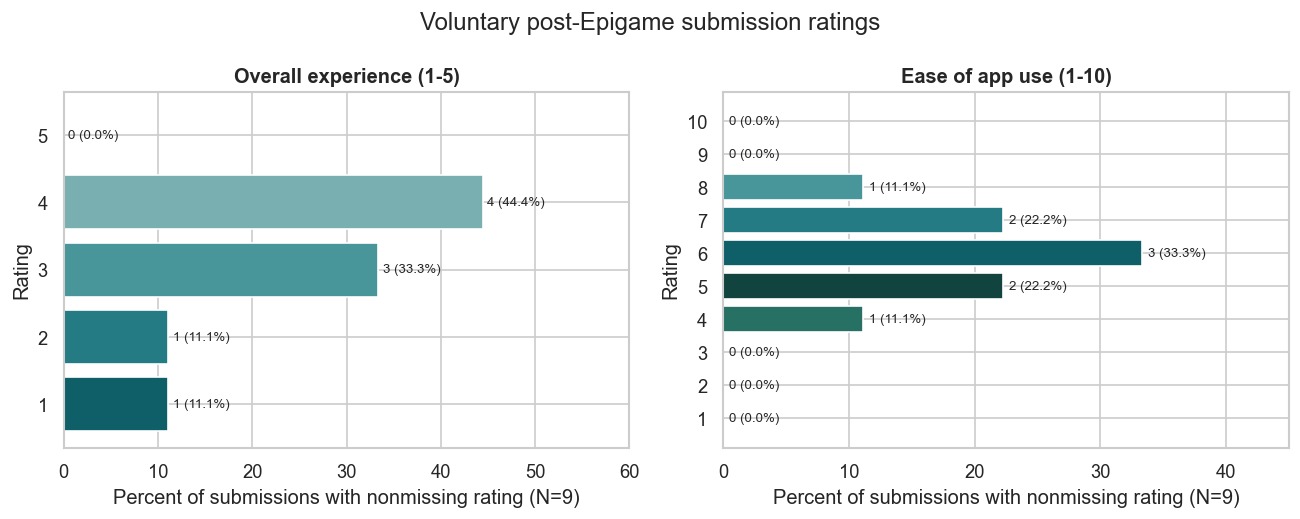

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
colors = ['#d9e2df', '#a8c5bd', '#5f9b8c', '#267064', '#12443f', '#0f5f69', '#257b83', '#49969a', '#79afb0', '#abd0ce']

for axis, (variable, specification) in zip(axes, rating_specs.items()):
    values = analysis_data[variable].dropna().astype(int)
    levels = np.arange(specification['minimum'], specification['maximum'] + 1)
    counts = values.value_counts().reindex(levels, fill_value=0)
    percentages = 100 * counts / len(values)
    palette = colors[-len(levels):]
    bars = axis.barh(levels.astype(str), percentages, color=palette)
    for bar, count, percent in zip(bars, counts, percentages):
        axis.text(percent + 0.5, bar.get_y() + bar.get_height() / 2, f'{count} ({percent:.1f}%)', va='center', fontsize=8)
    axis.set_title(specification['label'])
    axis.set_xlabel(f'Percent of submissions with nonmissing rating (N={len(values)})')
    axis.set_ylabel('Rating')
    axis.set_xlim(0, max(percentages.max() * 1.35, 25))

fig.suptitle('Voluntary post-Epigame submission ratings')
fig.tight_layout()
ratings_figure_base = OUTPUT_DIR / 'post-epigame-feedback-ratings'
fig.savefig(ratings_figure_base.with_suffix('.pdf'), bbox_inches='tight')
fig.savefig(ratings_figure_base.with_suffix('.png'), dpi=600, bbox_inches='tight')
plt.show()

## 9. Summarize Free-Text Feedback

Free text is normalized only for matching: Unicode NFKC normalization, case-folding, and whitespace collapse. Original text is not displayed or exported. Exact or near-exact comments meaning "none" or "no comment" are counted separately. Theme rules are regular expressions grounded in the survey topics and observed English vocabulary.

Theme matches may overlap because one comment can mention several ideas. Counts use substantive comments to the relevant prompt as their denominator. Keyword coding is reproducible descriptive indexing, not sentiment analysis or validated qualitative coding. To reduce disclosure risk and avoid emphasizing isolated comments, themes mentioned by fewer than three respondents are not displayed or exported.

In [7]:
def normalize_text(value):
    if pd.isna(value):
        return ''
    return re.sub(r'\s+', ' ', unicodedata.normalize('NFKC', str(value)).casefold()).strip()

NO_COMMENT_PATTERN = re.compile(
    r'^(?:no|none|nothing|nope|not really|no comments?|no ideas?|no issues?|'
    r'không|không có|không ạ|không có gì|không có ý kiến|không gặp|'
    r'ko|ko có|k|hông|hông ạ|chưa|nil)[\s.!?,;:]*$'
)

THEME_DICTIONARIES = {
    'enjoyed': {
        'Points and rewards': r'\bpoints?|rewards?|score|leaderboard\b|điểm|phần thưởng|xếp hạng',
        'Quarantine and daily choice': r'quarantin|isolat|daily choice|decision|cách ly|quyết định|lựa chọn',
        'Social contact and Bluetooth': r'bluetooth|contact|nearby|interact|friends?|social|tiếp xúc|kết nối|tương tác|bạn bè',
        'Avatar and customization': r'avatar|character|pet|customi[sz]|nhân vật|hình đại diện|trang phục|tùy chỉnh',
        'Health and protection mechanics': r'mask|medicine|vaccine|infection|disease|health|khẩu trang|thuốc|vắc|nhiễm|bệnh',
        'Realism and risk-reward tradeoff': r'risk|trade.?off|real life|realistic|balance|rủi ro|đời thực|thực tế|đánh đổi|cân bằng',
    },
    'problems': {
        'Bluetooth and contact detection': r'bluetooth|contact detect|connection|kết nối|tiếp xúc|không.*(?:thấy|tìm).*người',
        'Notifications and decision window': r'notif|remind|decision window|missed? .*day|thông báo|nhắc|khung giờ|thời gian.*chọn|quên',
        'Shop or items unavailable': r'\bshop\b|store|item|purchase|buy|cửa hàng|mua|vật phẩm',
        'Account, ID, or data loss': r'sign.?out|log.?out|account|\bid\b|reset|lost .*data|mất.*(?:dữ liệu|id|tài khoản)|đăng xuất|đổi.*id',
        'Performance, loading, or crashes': r'\bbug|bugs|lag|load|slow|crash|freeze|lỗi|chậm|đơ|treo',
        'Interface, survey, or accessibility': r'\bui\b|interface|survey|screen|button|display|giao diện|khảo sát|màn hình|nút',
        'Health-state or infection logic': r'recover|recovery|sick|medicine|infect|mask|bệnh|hồi phục|thuốc|nhiễm|khẩu trang',
        'Gameplay clarity or limited choice': r'unclear|confus|instruction|limited choice|not realistic|how .*work|không hiểu|hướng dẫn|ít lựa chọn|không.*thực tế',
    },
    'improvements': {
        'Avatar and customization': r'avatar|character|customi[sz]|clothes|accessor|color|nhân vật|hình đại diện|tùy chỉnh|trang phục|phụ kiện|màu',
        'More challenges and activities': r'challeng|activit|mini.?game|quest|quiz|thử thách|hoạt động|trò chơi|nhiệm vụ|câu hỏi',
        'Rewards, shop, and items': r'reward|points?|shop|store|item|purchase|buy|phần thưởng|điểm|cửa hàng|vật phẩm|mua',
        'Social interaction': r'interact|friends?|social|team|contact|tương tác|bạn bè|đội|tiếp xúc|người khác',
        'Notifications and reminders': r'notif|remind|alert|thông báo|nhắc',
        'Health and protection mechanics': r'mask|medicine|vaccine|treatment|infect|disease|khẩu trang|thuốc|vắc|điều trị|nhiễm|bệnh',
        'Realism, information, and feedback': r'real|information|explain|feedback|source|risk|thực tế|thông tin|giải thích|phản hồi|nguồn|rủi ro',
        'Interface and performance': r'\bui\b|interface|design|load|lag|performance|giao diện|thiết kế|chậm|mượt',
    },
}

for family, themes in THEME_DICTIONARIES.items():
    print(f'\n{family.upper()} THEMES')
    for theme, pattern in themes.items():
        print(f'- {theme}: {pattern}')


ENJOYED THEMES
- Points and rewards: \bpoints?|rewards?|score|leaderboard\b|điểm|phần thưởng|xếp hạng
- Quarantine and daily choice: quarantin|isolat|daily choice|decision|cách ly|quyết định|lựa chọn
- Social contact and Bluetooth: bluetooth|contact|nearby|interact|friends?|social|tiếp xúc|kết nối|tương tác|bạn bè
- Avatar and customization: avatar|character|pet|customi[sz]|nhân vật|hình đại diện|trang phục|tùy chỉnh
- Health and protection mechanics: mask|medicine|vaccine|infection|disease|health|khẩu trang|thuốc|vắc|nhiễm|bệnh
- Realism and risk-reward tradeoff: risk|trade.?off|real life|realistic|balance|rủi ro|đời thực|thực tế|đánh đổi|cân bằng

PROBLEMS THEMES
- Bluetooth and contact detection: bluetooth|contact detect|connection|kết nối|tiếp xúc|không.*(?:thấy|tìm).*người
- Notifications and decision window: notif|remind|decision window|missed? .*day|thông báo|nhắc|khung giờ|thời gian.*chọn|quên
- Shop or items unavailable: \bshop\b|store|item|purchase|buy|cửa hàng|mua|vật phẩm


In [9]:
prompt_specs = {
    'enjoyed': {'label': 'Most enjoyed elements', 'family': 'enjoyed'},
    'frustrations': {'label': 'Frustrations', 'family': 'problems'},
    'technical_issues': {'label': 'Technical issues', 'family': 'problems'},
    'improvements': {'label': 'General improvements', 'family': 'improvements'},
    'avatar_improvements': {'label': 'Avatar improvements', 'family': 'improvements'},
    'other_comments': {'label': 'Other comments', 'family': None},
}

completeness_rows = []
theme_rows = []

for variable, specification in prompt_specs.items():
    normalized = analysis_data[variable].map(normalize_text)
    answered = normalized.ne('')
    explicit_none = normalized.map(lambda text: bool(NO_COMMENT_PATTERN.fullmatch(text)) if text else False)
    substantive = answered & ~explicit_none
    matched_any = pd.Series(False, index=analysis_data.index)

    if specification['family'] is not None:
        for theme, pattern in THEME_DICTIONARIES[specification['family']].items():
            matched = substantive & normalized.str.contains(pattern, regex=True, na=False)
            matched_any |= matched
            theme_rows.append({
                'family': specification['family'],
                'prompt': variable,
                'prompt_label': specification['label'],
                'theme': theme,
                'count': int(matched.sum()),
                'substantive_denominator': int(substantive.sum()),
                'percent_of_substantive_comments': 100 * matched.sum() / substantive.sum() if substantive.sum() else np.nan,
            })

    completeness_rows.append({
        'prompt': variable,
        'prompt_label': specification['label'],
        'submitted_forms': len(analysis_data),
        'answered': int(answered.sum()),
        'explicit_no_comment': int(explicit_none.sum()),
        'substantive_comments': int(substantive.sum()),
    })

completeness_summary = pd.DataFrame(completeness_rows)
theme_summary = pd.DataFrame(theme_rows)
reportable_prompt_themes = theme_summary.query('count >= @THEME_REPORTING_THRESHOLD').copy()

display(completeness_summary)
print(f'Reportable prompt-level themes: {len(reportable_prompt_themes)}')
if len(reportable_prompt_themes):
    display(reportable_prompt_themes.sort_values(['family', 'prompt', 'count'], ascending=[True, True, False]).round(1))

,prompt,prompt_label,submitted_forms,answered,explicit_no_comment,substantive_comments
0,enjoyed,Most enjoyed elements,9,7,0,7
1,frustrations,Frustrations,9,8,0,8
2,technical_issues,Technical issues,9,7,0,7
3,improvements,General improvements,9,8,0,8
4,avatar_improvements,Avatar improvements,9,7,1,6
5,other_comments,Other comments,9,6,3,3


Reportable prompt-level themes: 6


,family,prompt,prompt_label,theme,count,substantive_denominator,percent_of_substantive_comments
0,enjoyed,enjoyed,Most enjoyed elements,Points and rewards,4,7,57.1
30,improvements,avatar_improvements,Avatar improvements,Avatar and customization,4,6,66.7
24,improvements,improvements,General improvements,"Rewards, shop, and items",5,8,62.5
28,improvements,improvements,General improvements,"Realism, information, and feedback",3,8,37.5
14,problems,technical_issues,Technical issues,Bluetooth and contact detection,4,7,57.1
18,problems,technical_issues,Technical issues,"Performance, loading, or crashes",3,7,42.9


## 10. Consolidate Post-Epigame Feedback

The ratings figure preserves every response level. Related narrative prompts are combined at the respondent level into three domains: enjoyed elements, reported problems, and suggested improvements. Each submission is counted at most once per theme within a domain. Because only nine forms were submitted, no theme prevalence figure is produced; only themes with at least three respondents are retained in aggregate tables.

In [10]:
family_sources = {
    'enjoyed': ['enjoyed'],
    'problems': ['frustrations', 'technical_issues'],
    'improvements': ['improvements', 'avatar_improvements'],
}
family_labels = {
    'enjoyed': 'Enjoyed elements',
    'problems': 'Reported problems',
    'improvements': 'Suggested improvements',
}

family_theme_rows = []
for family, variables in family_sources.items():
    combined_text = analysis_data[variables].fillna('').astype(str).agg(' '.join, axis=1).map(normalize_text)
    substantive_parts = []
    for variable in variables:
        normalized_part = analysis_data[variable].map(normalize_text)
        substantive_parts.append(
            normalized_part.ne('')
            & ~normalized_part.map(lambda text: bool(NO_COMMENT_PATTERN.fullmatch(text)) if text else False)
        )
    substantive_family = pd.concat(substantive_parts, axis=1).any(axis=1)
    substantive_denominator = int(substantive_family.sum())

    for theme, pattern in THEME_DICTIONARIES[family].items():
        matched = substantive_family & combined_text.str.contains(pattern, regex=True, na=False)
        count = int(matched.sum())
        family_theme_rows.append({
            'family': family,
            'family_label': family_labels[family],
            'theme': theme,
            'count': count,
            'substantive_denominator': substantive_denominator,
            'all_submissions_denominator': len(analysis_data),
            'percent_of_substantive_submissions': 100 * count / substantive_denominator if substantive_denominator else np.nan,
            'percent_of_all_submissions': 100 * count / len(analysis_data),
        })

family_theme_summary = pd.DataFrame(family_theme_rows)
reportable_family_themes = family_theme_summary.query('count >= @THEME_REPORTING_THRESHOLD').copy()

print(
    f'Reportable narrative themes (at least {THEME_REPORTING_THRESHOLD} respondents): '
    f'{len(reportable_family_themes)}'
)
if len(reportable_family_themes):
    display(reportable_family_themes.sort_values(['family', 'count'], ascending=[True, False]).round(1))
else:
    print('No narrative theme met the reporting threshold; no theme figure will be generated.')

Reportable narrative themes (at least 3 respondents): 6


,family,family_label,theme,count,substantive_denominator,all_submissions_denominator,percent_of_substantive_submissions,percent_of_all_submissions
0,enjoyed,Enjoyed elements,Points and rewards,4,7,9,57.1,44.4
14,improvements,Suggested improvements,Avatar and customization,5,8,9,62.5,55.6
16,improvements,Suggested improvements,"Rewards, shop, and items",5,8,9,62.5,55.6
20,improvements,Suggested improvements,"Realism, information, and feedback",3,8,9,37.5,33.3
6,problems,Reported problems,Bluetooth and contact detection,4,8,9,50.0,44.4
10,problems,Reported problems,"Performance, loading, or crashes",3,8,9,37.5,33.3


## 11. Export Aggregate Tables and Figures

Exports contain aggregate summaries only: no response-level combinations, timestamps, or verbatim free text. Stale response-level and sparse-theme files are removed if present. The manuscript-ready table reports the two rating summaries and narrative themes mentioned by at least three respondents. Counts are primary; percentages are descriptive aids and must not be generalized beyond these nine voluntary submissions.

In [11]:
for stale_name in [
    'post-epigame-feedback-deidentified.csv',
    'post-epigame-feedback-themes.csv',
    'post-epigame-feedback-family-themes.csv',
    'post-epigame-feedback-themes.pdf',
    'post-epigame-feedback-themes.png',
]:
    (OUTPUT_DIR / stale_name).unlink(missing_ok=True)

rating_findings = rating_summary.assign(
    domain='rating',
    result=lambda frame: frame.apply(
        lambda row: f"median {row['median']:.1f} (IQR {row['q1']:.1f}-{row['q3']:.1f}); "
                    f"{row['favorable_count']}/{row['n']} ({row['favorable_percent']:.1f}%) favorable",
        axis=1,
    ),
)[['domain', 'item', 'n', 'result']]

if len(reportable_family_themes):
    theme_findings = reportable_family_themes.assign(
        domain=lambda frame: frame['family_label'],
        item=lambda frame: frame['theme'],
        n=lambda frame: frame['substantive_denominator'],
        result=lambda frame: frame.apply(
            lambda row: f"{row['count']}/{row['substantive_denominator']} "
                        f"({row['percent_of_substantive_submissions']:.1f}%) among substantive submissions",
            axis=1,
        ),
    )[['domain', 'item', 'n', 'result']]
else:
    theme_findings = pd.DataFrame(columns=['domain', 'item', 'n', 'result'])

manuscript_ready_summary = pd.concat([rating_findings, theme_findings], ignore_index=True)

output_tables = {
    'post-epigame-feedback-rating-summary.csv': rating_summary,
    'post-epigame-feedback-completeness.csv': completeness_summary,
    'post-epigame-feedback-reportable-themes.csv': reportable_family_themes,
    'post-epigame-feedback-manuscript-summary.csv': manuscript_ready_summary,
}
for filename, table in output_tables.items():
    table.to_csv(OUTPUT_DIR / filename, index=False)

excel_path = OUTPUT_DIR / 'post-epigame-feedback-publication-tables.xlsx'
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    rating_summary.to_excel(writer, sheet_name='ratings', index=False)
    completeness_summary.to_excel(writer, sheet_name='completeness', index=False)
    reportable_family_themes.to_excel(writer, sheet_name='reportable_themes', index=False)
    manuscript_ready_summary.to_excel(writer, sheet_name='manuscript_summary', index=False)

display(manuscript_ready_summary)
print('\nCautious interpretation')
print('- Results describe nine voluntary submissions only and cannot establish prevalence or general acceptability.')
print('- Percentages are shown only to clarify counts and should not be generalized to randomized participants.')
print(f'- Narrative themes are omitted unless mentioned by at least {THEME_REPORTING_THRESHOLD} respondents.')
print('- Keyword indexing is descriptive, permits overlapping themes, and is not validated qualitative analysis.')

print('\nGenerated aggregate outputs')
for output_path in sorted(OUTPUT_DIR.iterdir()):
    print(output_path)

,domain,item,n,result
0,rating,Overall experience (1-5),9,median 3.0 (IQR 3.0-4.0); 4/9 (44.4%) favorable
1,rating,Ease of app use (1-10),9,median 6.0 (IQR 5.0-7.0); 1/9 (11.1%) favorable
2,Enjoyed elements,Points and rewards,7,4/7 (57.1%) among substantive submissions
3,Reported problems,Bluetooth and contact detection,8,4/8 (50.0%) among substantive submissions
4,Reported problems,"Performance, loading, or crashes",8,3/8 (37.5%) among substantive submissions
5,Suggested improvements,Avatar and customization,8,5/8 (62.5%) among substantive submissions
6,Suggested improvements,"Rewards, shop, and items",8,5/8 (62.5%) among substantive submissions
7,Suggested improvements,"Realism, information, and feedback",8,3/8 (37.5%) among substantive submissions



Cautious interpretation
- Results describe nine voluntary submissions only and cannot establish prevalence or general acceptability.
- Percentages are shown only to clarify counts and should not be generalized to randomized participants.
- Narrative themes are omitted unless mentioned by at least 3 respondents.
- Keyword indexing is descriptive, permits overlapping themes, and is not validated qualitative analysis.

Generated aggregate outputs
output/202/post-epigame-feedback/post-epigame-feedback-completeness.csv
output/202/post-epigame-feedback/post-epigame-feedback-manuscript-summary.csv
output/202/post-epigame-feedback/post-epigame-feedback-publication-tables.xlsx
output/202/post-epigame-feedback/post-epigame-feedback-rating-summary.csv
output/202/post-epigame-feedback/post-epigame-feedback-ratings.pdf
output/202/post-epigame-feedback/post-epigame-feedback-ratings.png
output/202/post-epigame-feedback/post-epigame-feedback-reportable-themes.csv
